In [2]:
# ============================================================
# Import necessary libraries and modules
# ============================================================

import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

from src.train_model import train_baseline_model, train_random_forest, train_lightgbm
from sklearn.metrics import roc_auc_score, roc_curve

pd.set_option('display.max_columns', None)

print("✓ Imports successful")

✓ Imports successful


In [3]:
# ============================================================
# Load data and config
# ============================================================

# Loading processed data
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Loading config
with open('../config/model_config.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

print("=" * 60)
print("MODEL TRAINING")
print("=" * 60)

print(f"\n Data loaded:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test: {X_test.shape}")
print(f"  y_train: {y_train.shape} (positive: {y_train.sum()} / {y_train.mean():.2%})")
print(f"  y_test: {y_test.shape} (positive: {y_test.sum()} / {y_test.mean():.2%})")

MODEL TRAINING

 Data loaded:
  X_train: (66030, 14)
  X_test: (13846, 14)
  y_train: (66030,) (positive: 5931.0 / 8.98%)
  y_test: (13846,) (positive: 1196.0 / 8.64%)


In [4]:
# ============================================================
# Baseline — Logistic Regression
# ============================================================

lr_model = train_baseline_model(X_train, y_train, config)

# Predictions on test
y_test_pred_lr = lr_model.predict_proba(X_test)[:, 1]
test_auc_lr = roc_auc_score(y_test, y_test_pred_lr)

print(f"\n✓ Test ROC-AUC: {test_auc_lr:.4f}")


TRAINING BASELINE MODEL: Logistic Regression

✓ Model trained
  Train ROC-AUC: 0.5605

✓ Test ROC-AUC: 0.6012


c:\Users\seka_\Portfolio_projects\call-result-prediction\venv_ml\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [5]:
# ============================================================
# Random Forest
# ============================================================

rf_model = train_random_forest(X_train, y_train, config)

# Predictions on test
y_test_pred_rf = rf_model.predict_proba(X_test)[:, 1]
test_auc_rf = roc_auc_score(y_test, y_test_pred_rf)

print(f"\n✓ Test ROC-AUC: {test_auc_rf:.4f}")


TRAINING MODEL: Random Forest

✓ Model trained
  Train ROC-AUC: 0.8421

✓ Test ROC-AUC: 0.5866


In [6]:
# ============================================================
# LightGBM
# ============================================================

lgbm_model = train_lightgbm(X_train, y_train, config)

# Predictions on test
y_test_pred_lgbm = lgbm_model.predict_proba(X_test)[:, 1]
test_auc_lgbm = roc_auc_score(y_test, y_test_pred_lgbm)

print(f"\n✓ Test ROC-AUC: {test_auc_lgbm:.4f}")


TRAINING MODEL: LightGBM

✓ Model trained
  Train ROC-AUC: 0.7534

✓ Test ROC-AUC: 0.5761


MODEL COMPARISON


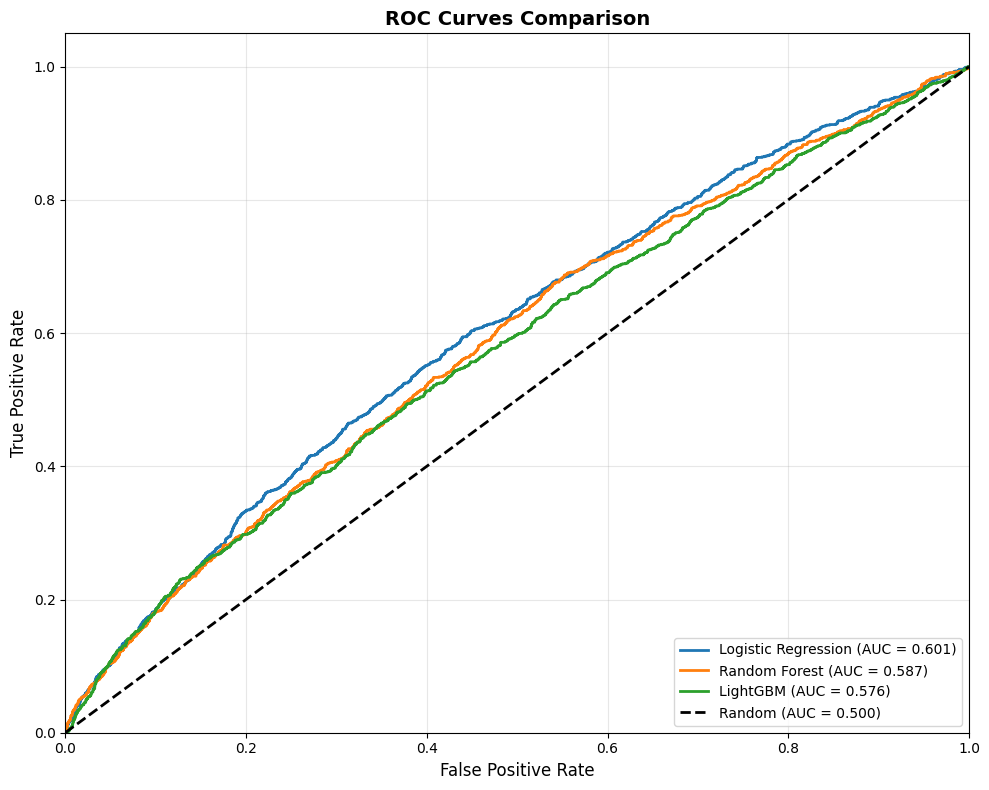

In [7]:
# ============================================================
# Comparison of Models — ROC Curves
# ============================================================

print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

fig, ax = plt.subplots(figsize=(10, 8))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_test_pred_lr)
ax.plot(fpr_lr, tpr_lr, linewidth=2, label=f'Logistic Regression (AUC = {test_auc_lr:.3f})')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_test_pred_rf)
ax.plot(fpr_rf, tpr_rf, linewidth=2, label=f'Random Forest (AUC = {test_auc_rf:.3f})')

# LightGBM
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_test_pred_lgbm)
ax.plot(fpr_lgbm, tpr_lgbm, linewidth=2, label=f'LightGBM (AUC = {test_auc_lgbm:.3f})')

# Random baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (AUC = 0.500)')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves Comparison', fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


 Model Performance Comparison:

              Model  Test ROC-AUC
Logistic Regression      0.601202
      Random Forest      0.586592
           LightGBM      0.576061


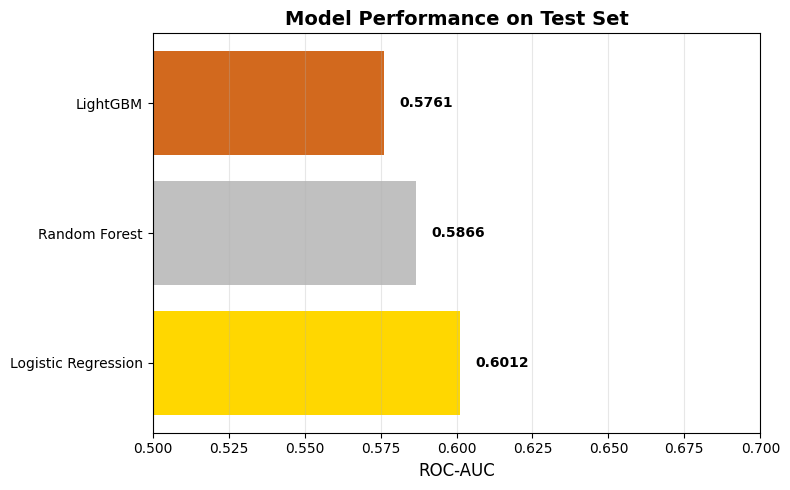


 Best Model: Logistic Regression (ROC-AUC: 0.6012)


In [8]:
# ============================================================
# Comparison of Metrics
# ============================================================

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'LightGBM'],
    'Test ROC-AUC': [test_auc_lr, test_auc_rf, test_auc_lgbm]
}).sort_values('Test ROC-AUC', ascending=False)

print("\n Model Performance Comparison:\n")
print(comparison_df.to_string(index=False))

# Визуализация
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(comparison_df['Model'], comparison_df['Test ROC-AUC'], color=['gold', 'silver', 'chocolate'])
ax.set_xlabel('ROC-AUC', fontsize=12)
ax.set_title('Model Performance on Test Set', fontsize=14, fontweight='bold')
ax.set_xlim([0.5, 0.7])
ax.grid(alpha=0.3, axis='x')

for i, v in enumerate(comparison_df['Test ROC-AUC'].values):
    ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Лучшая модель
best_model_name = comparison_df.iloc[0]['Model']
best_auc = comparison_df.iloc[0]['Test ROC-AUC']

print(f"\n Best Model: {best_model_name} (ROC-AUC: {best_auc:.4f})")

In [9]:
# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 60)
print("✓✓✓ MODELING COMPLETE ✓✓✓")
print("=" * 60)

print("\n Summary:")
print(f"  Best Model: {best_model_name}")
print(f"  Test ROC-AUC: {best_auc:.4f}")
print(f"\n  All models trained successfully!")


✓✓✓ MODELING COMPLETE ✓✓✓

 Summary:
  Best Model: Logistic Regression
  Test ROC-AUC: 0.6012

  All models trained successfully!
